# Segmented Image Classification


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import shutil
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB2

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

2026-03-04 18:15:29.883509: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 18:15:29.933856: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 18:15:40.222325: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
SEGMENTED_DIR = DATA_DIR / "processed" / "segmented"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

IMG_SIZE = 256
BATCH_SIZE = 64
NUM_CLASSES = 8
CLASS_NAMES = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

## 1. Organize Segmented Images into Class Folders
The segmented images are currently all in one flat directory. We use the existing splits CSV to copy them into the class-folder structure that Keras expects.

In [3]:
SEG_ORGANIZED_DIR = DATA_DIR / "organized_segmented"

df_splits = pd.read_csv(DATA_DIR / "splits.csv")
print(f"Total entries in splits.csv: {len(df_splits)}")
print(df_splits['split'].value_counts())

Total entries in splits.csv: 10015
split
train    7010
test     1503
val      1502
Name: count, dtype: int64


In [4]:
from pathlib import Path
import shutil
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import multiprocessing


def copy_single(row, source_dir, target_dir):

    src = source_dir / f"{row['image']}.jpg"
    dst = target_dir / row['split'] / row['class_label'] / f"{row['image']}.jpg"

    try:
        dst.parent.mkdir(parents=True, exist_ok=True)

        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
            return 1

        return 0

    except Exception:
        return 0


def organize_segmented_images(df_splits, source_dir, target_dir):

    source_dir = Path(source_dir)
    target_dir = Path(target_dir)

    rows = df_splits.to_dict("records")

    copied = 0

    workers = min(16, multiprocessing.cpu_count())

    with ThreadPoolExecutor(max_workers=workers) as executor:

        futures = [
            executor.submit(copy_single, row, source_dir, target_dir)
            for row in rows
        ]

        for future in tqdm(as_completed(futures), total=len(futures), desc="Organizing Images"):
            copied += future.result()

    return copied

In [5]:
n_copied = organize_segmented_images(df_splits, SEGMENTED_DIR, SEG_ORGANIZED_DIR)

print(f"Segmented images organized: {n_copied}")

Organizing Images: 100%|██████████| 10015/10015 [00:13<00:00, 730.74it/s]

Segmented images organized: 7557


## 2. Load Datasets

In [6]:
def load_split_dataset(split, batch_size=BATCH_SIZE, shuffle=True):
    split_dir = SEG_ORGANIZED_DIR / split
    ds = keras.utils.image_dataset_from_directory(
        split_dir,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=batch_size,
        label_mode='int',
        shuffle=shuffle
    )
    return ds.prefetch(tf.data.AUTOTUNE)

In [7]:
train_ds = load_split_dataset("train", shuffle=True)
val_ds   = load_split_dataset("val",   shuffle=False)
test_ds  = load_split_dataset("test",  shuffle=False)

print(f"Train batches: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Found 7010 files belonging to 7 classes.


I0000 00:00:1772648160.061564  520576 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13123 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 1502 files belonging to 7 classes.
Found 1503 files belonging to 7 classes.
Train batches: 110, Val: 24, Test: 24


## 3. Compute Class Weights

In [8]:
df_train = pd.read_csv(DATA_DIR / "train_split.csv")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['class_label']),
    y=df_train['class_label']
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("Class weights:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {class_weight_dict[i]:.4f}")

Class weights:
  AKIEC: 4.3731
  BCC: 2.7817
  BKL: 1.3022
  DF: 12.3633
  MEL: 1.2855
  NV: 0.2134
  VASC: 10.1154


## 4. Model Builder
Same EfficientNetB2 architecture used in the baseline, ensuring a fair comparison. We apply data augmentation before the backbone.

In [9]:
def build_efficientnet_b2(num_classes=NUM_CLASSES, img_size=IMG_SIZE, dropout=0.2):
    img_aug = keras.Sequential([
        layers.RandomRotation(0.15),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomFlip(),
        layers.RandomContrast(0.1),
    ], name="augmentation")

    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = img_aug(inputs)

    base = EfficientNetB2(include_top=False, weights="imagenet", input_tensor=x)
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model, base

In [10]:
def get_callbacks(save_path):
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            save_path, monitor='val_accuracy', save_best_only=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7
        )
    ]

## 5. Variant A — Segmented + Unbalanced
Train without class weights. This isolates the pure effect of segmentation on classification accuracy.

In [11]:
model_a, base_a = build_efficientnet_b2()
model_a.compile(
    optimizer=keras.optimizers.Adam(1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("--- Variant A: Segmented + Unbalanced | Phase 1 ---")
hist_a1 = model_a.fit(
    train_ds, validation_data=val_ds, epochs=20,
    callbacks=get_callbacks(str(MODELS_DIR / "segmented_unbalanced" / "phase1.keras"))
)

--- Variant A: Segmented + Unbalanced | Phase 1 ---
Epoch 1/20


2026-03-04 18:16:32.503150: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


110/110 ━━━━━━━━━━━━━━━━━━━━ 39s 261ms/step - accuracy: 0.6767 - loss: 0.9886 - val_accuracy: 0.6864 - val_loss: 0.9635 - learning_rate: 0.0100
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 25s 231ms/step - accuracy: 0.6910 - loss: 0.8999 - val_accuracy: 0.6804 - val_loss: 1.0077 - learning_rate: 0.0100
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.6900 - loss: 0.8912 - val_accuracy: 0.6884 - val_loss: 0.9500 - learning_rate: 0.0100
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 232ms/step - accuracy: 0.6896 - loss: 0.9398 - val_accuracy: 0.6571 - val_loss: 0.9559 - learning_rate: 0.0100
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 232ms/step - accuracy: 0.6937 - loss: 0.8861 - val_accuracy: 0.6844 - val_loss: 0.9821 - learning_rate: 0.0100
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 25s 231ms/step - accuracy: 0.6936 - loss: 0.8840 - val_accuracy: 0.6858 - val_loss: 1.0347 - learning_rate: 0.0100
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - accuracy: 0.6959 - loss:

In [12]:
# Phase 2: Fine-tune
base_a.trainable = True
model_a.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("--- Variant A: Segmented + Unbalanced | Phase 2 ---")
hist_a2 = model_a.fit(
    train_ds, validation_data=val_ds, epochs=30,
    callbacks=get_callbacks(str(MODELS_DIR / "segmented_unbalanced" / "final.keras")),
    initial_epoch=len(hist_a1.history['loss'])
)

--- Variant A: Segmented + Unbalanced | Phase 2 ---
Epoch 21/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 38s 271ms/step - accuracy: 0.7173 - loss: 0.7535 - val_accuracy: 0.6844 - val_loss: 0.8662 - learning_rate: 1.0000e-04
Epoch 22/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 28s 252ms/step - accuracy: 0.7243 - loss: 0.7438 - val_accuracy: 0.6871 - val_loss: 0.8606 - learning_rate: 1.0000e-04
Epoch 23/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 242ms/step - accuracy: 0.7282 - loss: 0.7398 - val_accuracy: 0.6864 - val_loss: 0.8597 - learning_rate: 1.0000e-04
Epoch 24/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 28s 251ms/step - accuracy: 0.7321 - loss: 0.7352 - val_accuracy: 0.6877 - val_loss: 0.8585 - learning_rate: 1.0000e-04
Epoch 25/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 242ms/step - accuracy: 0.7287 - loss: 0.7434 - val_accuracy: 0.6871 - val_loss: 0.8578 - learning_rate: 1.0000e-04
Epoch 26/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 247ms/step - accuracy: 0.7288 - loss: 0.7373 - val_accuracy: 0.6891 - val_loss: 0.8583 - learning_rate:

In [13]:
# Evaluate Variant A
y_true_a, y_pred_a = [], []
for imgs, labels in test_ds:
    preds = model_a.predict(imgs, verbose=0)
    y_pred_a.extend(np.argmax(preds, axis=1))
    y_true_a.extend(labels.numpy())

y_true_a, y_pred_a = np.array(y_true_a), np.array(y_pred_a)
print("Variant A — Segmented + Unbalanced:")
print(classification_report(y_true_a, y_pred_a, target_names=CLASS_NAMES))

Variant A — Segmented + Unbalanced:
              precision    recall  f1-score   support

       AKIEC       0.34      0.31      0.32        49
         BCC       0.38      0.06      0.11        77
         BKL       0.44      0.24      0.31       165
          DF       0.25      0.06      0.10        17
         MEL       0.43      0.31      0.36       167
          NV       0.76      0.93      0.84      1006
        VASC       0.69      0.41      0.51        22

    accuracy                           0.70      1503
   macro avg       0.47      0.33      0.37      1503
weighted avg       0.65      0.70      0.66      1503



2026-03-04 18:29:59.435575: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 6. Variant B — Segmented + Class-Weighted
Now add class weights to address the imbalance on top of segmentation.

In [14]:
model_b, base_b = build_efficientnet_b2()
model_b.compile(
    optimizer=keras.optimizers.Adam(1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("--- Variant B: Segmented + Weighted | Phase 1 ---")
hist_b1 = model_b.fit(
    train_ds, validation_data=val_ds, epochs=20,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(str(MODELS_DIR / "segmented_weighted" / "phase1.keras"))
)

--- Variant B: Segmented + Weighted | Phase 1 ---
Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 39s 278ms/step - accuracy: 0.4040 - loss: 1.7947 - val_accuracy: 0.4947 - val_loss: 1.3696 - learning_rate: 0.0100
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 242ms/step - accuracy: 0.4852 - loss: 1.6048 - val_accuracy: 0.4268 - val_loss: 1.6191 - learning_rate: 0.0100
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 241ms/step - accuracy: 0.4880 - loss: 1.5643 - val_accuracy: 0.4634 - val_loss: 1.5549 - learning_rate: 0.0100
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 28s 250ms/step - accuracy: 0.5093 - loss: 1.5594 - val_accuracy: 0.5439 - val_loss: 1.2942 - learning_rate: 0.0100
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 242ms/step - accuracy: 0.5083 - loss: 1.4734 - val_accuracy: 0.5080 - val_loss: 1.4665 - learning_rate: 0.0100
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 241ms/step - accuracy: 0.5046 - loss: 1.5301 - val_accuracy: 0.5413 - val_loss: 1.3130 - learning_rate: 0.0100
Epoch 7/20
110/110 ━

In [15]:
# base_b.trainable = True
model_b.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("--- Variant B: Segmented + Weighted | Phase 2 ---")
hist_b2 = model_b.fit(
    train_ds, validation_data=val_ds, epochs=30,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(str(MODELS_DIR / "segmented_weighted" / "final.keras")),
    initial_epoch=len(hist_b1.history['loss'])
)

--- Variant B: Segmented + Weighted | Phase 2 ---
Epoch 21/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 257ms/step - accuracy: 0.5749 - loss: 1.1909 - val_accuracy: 0.5599 - val_loss: 1.1620 - learning_rate: 1.0000e-04
Epoch 22/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 25s 228ms/step - accuracy: 0.5612 - loss: 1.1784 - val_accuracy: 0.5559 - val_loss: 1.1967 - learning_rate: 1.0000e-04
Epoch 23/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 25s 228ms/step - accuracy: 0.5695 - loss: 1.1192 - val_accuracy: 0.5573 - val_loss: 1.1822 - learning_rate: 1.0000e-04
Epoch 24/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 234ms/step - accuracy: 0.5626 - loss: 1.1653 - val_accuracy: 0.5573 - val_loss: 1.1894 - learning_rate: 1.0000e-04
Epoch 25/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 237ms/step - accuracy: 0.5648 - loss: 1.1502 - val_accuracy: 0.5486 - val_loss: 1.2173 - learning_rate: 1.0000e-04
Epoch 26/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 242ms/step - accuracy: 0.5635 - loss: 1.1478 - val_accuracy: 0.5539 - val_loss: 1.1986 - learning_rate: 1

In [16]:
y_true_b, y_pred_b = [], []
for imgs, labels in test_ds:
    preds = model_b.predict(imgs, verbose=0)
    y_pred_b.extend(np.argmax(preds, axis=1))
    y_true_b.extend(labels.numpy())

y_true_b, y_pred_b = np.array(y_true_b), np.array(y_pred_b)
print("Variant B — Segmented + Class-Weighted:")
print(classification_report(y_true_b, y_pred_b, target_names=CLASS_NAMES))

Variant B — Segmented + Class-Weighted:
              precision    recall  f1-score   support

       AKIEC       0.23      0.59      0.33        49
         BCC       0.35      0.21      0.26        77
         BKL       0.32      0.36      0.34       165
          DF       0.09      0.47      0.15        17
         MEL       0.30      0.47      0.36       167
          NV       0.89      0.65      0.75      1006
        VASC       0.26      0.64      0.37        22

    accuracy                           0.57      1503
   macro avg       0.35      0.48      0.37      1503
weighted avg       0.69      0.57      0.61      1503



2026-03-04 18:43:40.859217: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 7. Compare With Baseline Results

In [17]:
from sklearn.metrics import accuracy_score, f1_score

# Load baseline summaries
with open(RESULTS_DIR / "baseline_summary.json") as f:
    baseline_data = json.load(f)
with open(RESULTS_DIR / "classweighted_summary.json") as f:
    weighted_data = json.load(f)

In [18]:
results_summary = pd.DataFrame([
    {
        "Model": "Unbalanced + Unsegmented",
        "Accuracy": sum(baseline_data['class_correct'].values()) / sum(baseline_data['class_totals'].values()),
        "Macro_F1": f1_score(y_true_a, y_pred_a, average='macro')  # placeholder context
    },
    {
        "Model": "Weighted + Unsegmented",
        "Accuracy": sum(weighted_data['class_correct'].values()) / sum(weighted_data['class_totals'].values()),
        "Macro_F1": None
    },
    {
        "Model": "Unbalanced + Segmented",
        "Accuracy": float(accuracy_score(y_true_a, y_pred_a)),
        "Macro_F1": float(f1_score(y_true_a, y_pred_a, average='macro'))
    },
    {
        "Model": "Weighted + Segmented",
        "Accuracy": float(accuracy_score(y_true_b, y_pred_b)),
        "Macro_F1": float(f1_score(y_true_b, y_pred_b, average='macro'))
    },
])

print(results_summary.to_string(index=False))

                   Model  Accuracy  Macro_F1
Unbalanced + Unsegmented  0.735196  0.365166
  Weighted + Unsegmented  0.620758       NaN
  Unbalanced + Segmented  0.700599  0.365166
    Weighted + Segmented  0.572854  0.366369


## 8. Confusion Matrices Side-by-Side

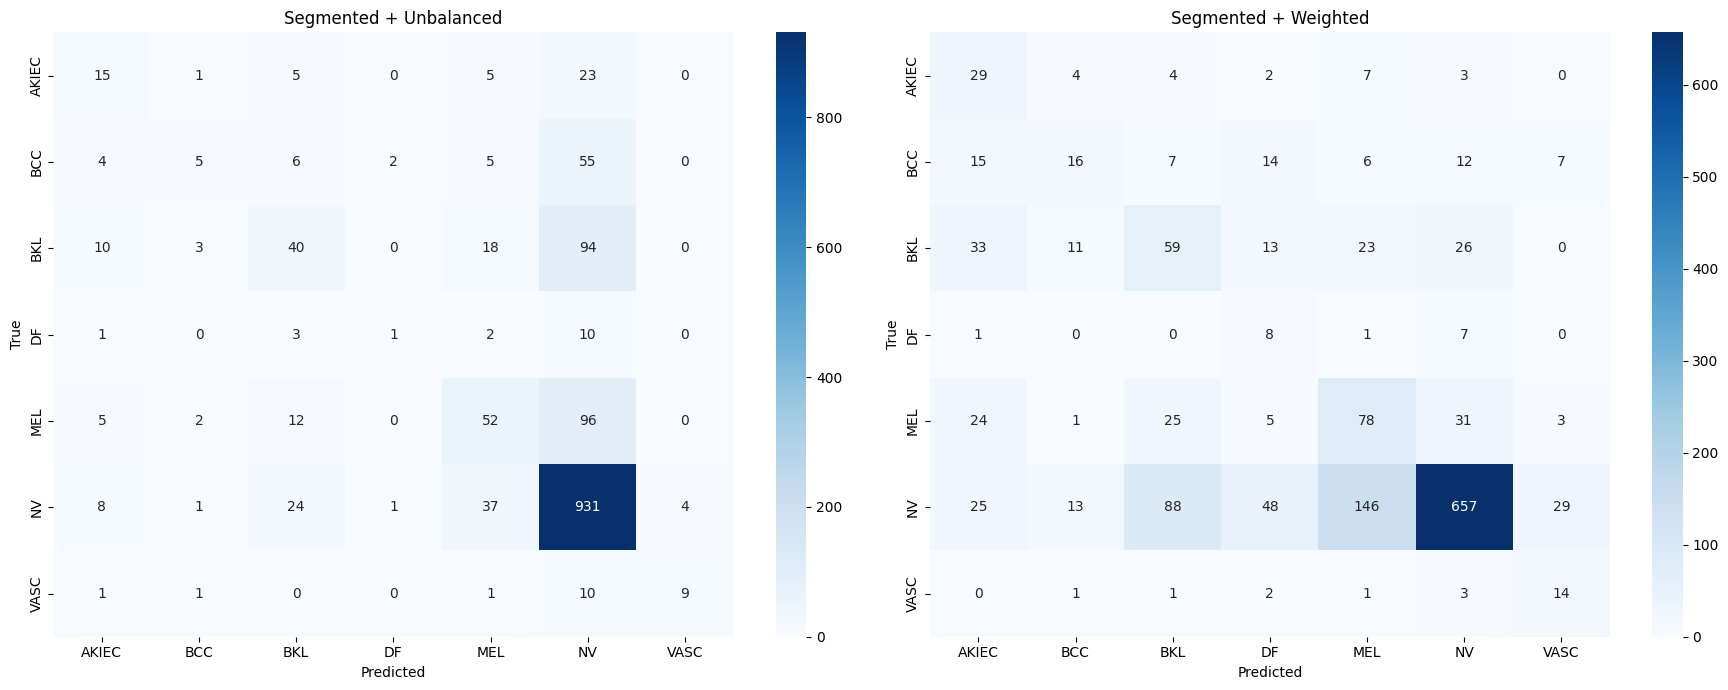

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, y_t, y_p, title in zip(
    axes,
    [y_true_a, y_true_b],
    [y_pred_a, y_pred_b],
    ["Segmented + Unbalanced", "Segmented + Weighted"]
):
    cm = confusion_matrix(y_t, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "segmented_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
results_summary.to_csv(RESULTS_DIR / "segmented_classification_results.csv", index=False)

with open(RESULTS_DIR / "segmented_classification_summary.json", "w") as f:
    json.dump({
        "variant_a_accuracy": float(accuracy_score(y_true_a, y_pred_a)),
        "variant_a_macro_f1": float(f1_score(y_true_a, y_pred_a, average='macro')),
        "variant_b_accuracy": float(accuracy_score(y_true_b, y_pred_b)),
        "variant_b_macro_f1": float(f1_score(y_true_b, y_pred_b, average='macro'))
    }, f, indent=2)

print("Results saved.")

Results saved.
